In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
from sklearn.model_selection import GridSearchCV

Przygotowanie danych
1.1. Wczytanie danych, sprawdzenie typów danych i kompletności danych, podstawowe statystyki.

In [ ]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


1.2. Utworzenie wykresu słupkowego:
1.2.1. ilości wystąpień kategorii dotyczącej atrybutu decyzyjnego,
1.2.2. atrybut decyzyjny według płci.

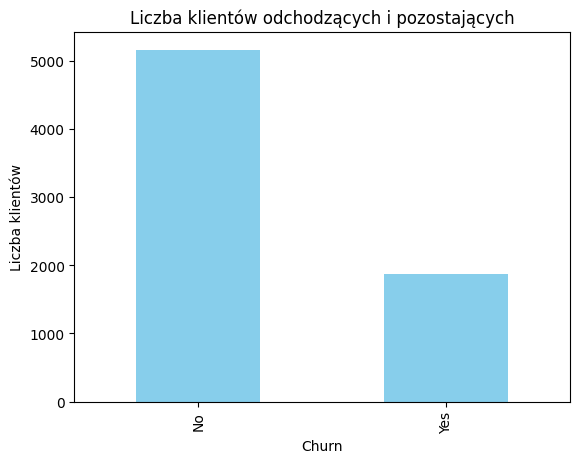

In [44]:
df['Churn'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Liczba klientów odchodzących i pozostających')
plt.xlabel('Churn')
plt.ylabel('Liczba klientów')
plt.show()

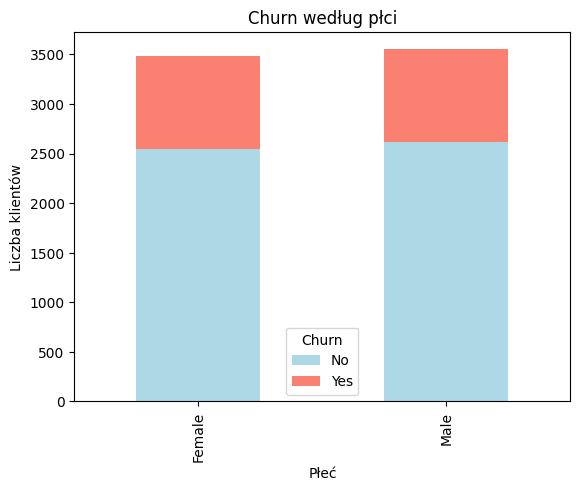

In [45]:
df.groupby(['gender', 'Churn']).size().unstack().plot(kind='bar', stacked=True, color=['lightblue', 'salmon'])
plt.title('Churn według płci')
plt.xlabel('Płeć')
plt.ylabel('Liczba klientów')
plt.show()


1.3. Wykres pudełkowy:
1.3.1. opłat całkowitych w zależności od klientów, którzy odeszli w ciągu ostatniego miesiąca.
1.3.2. ‘churn’ klientów w zależności długości czasu korzystania z usług.

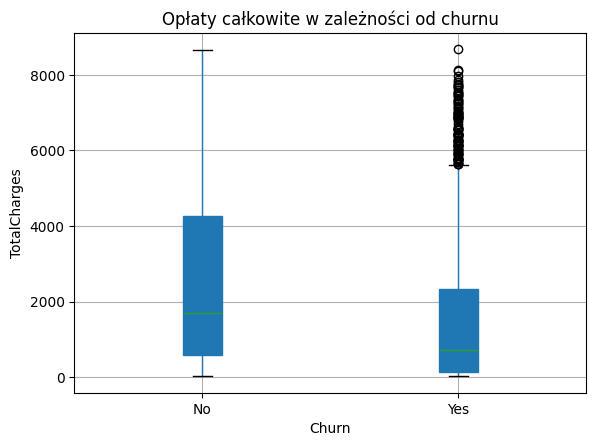

In [46]:
df.boxplot(column='TotalCharges', by='Churn', patch_artist=True)
plt.title('Opłaty całkowite w zależności od churnu')
plt.suptitle('')
plt.ylabel('TotalCharges')
plt.show()


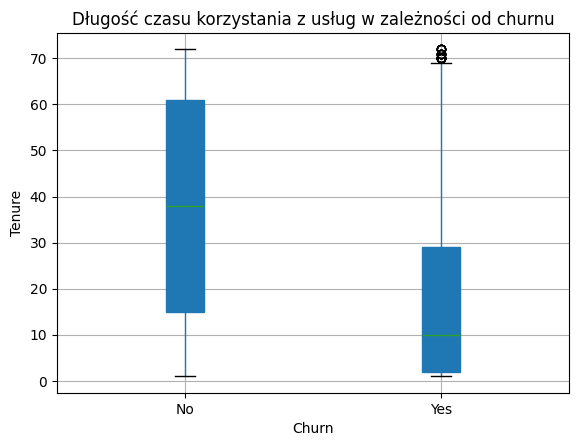

In [47]:
df.boxplot(column='tenure', by='Churn', patch_artist=True)
plt.title('Długość czasu korzystania z usług w zależności od churnu')
plt.suptitle('')
plt.ylabel('Tenure')
plt.show()


1.4. Wykres pudełkowy opłat całkowitych w zależności od rodzaju umowy z uwzględnieniem, klientów,
którzy odeszli w ciągu ostatniego miesiąca 'Churn'.

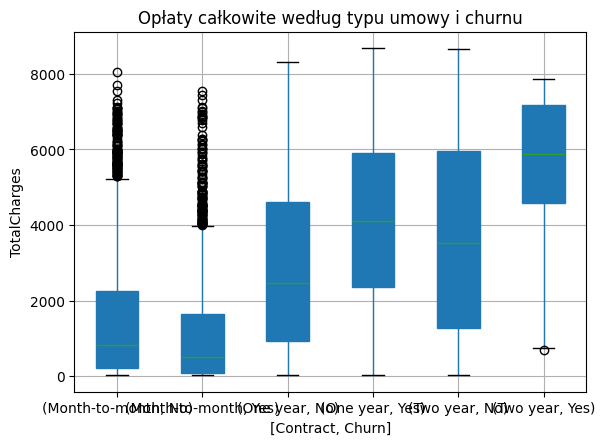

In [48]:
df.boxplot(column='TotalCharges', by=['Contract', 'Churn'], patch_artist=True)
plt.title('Opłaty całkowite według typu umowy i churnu')
plt.suptitle('')
plt.ylabel('TotalCharges')
plt.show()


1.5. Utworzenie wykresu słupkowego wielkości korelacji z wyłączeniem cech ('customerID', 'tenure',
'MonthlyCharges', 'TotalCharges') z ‘Churn’ yes. Niektóre kolumny kategorialne należy
przekonwertować na zmienne fikcyjne.

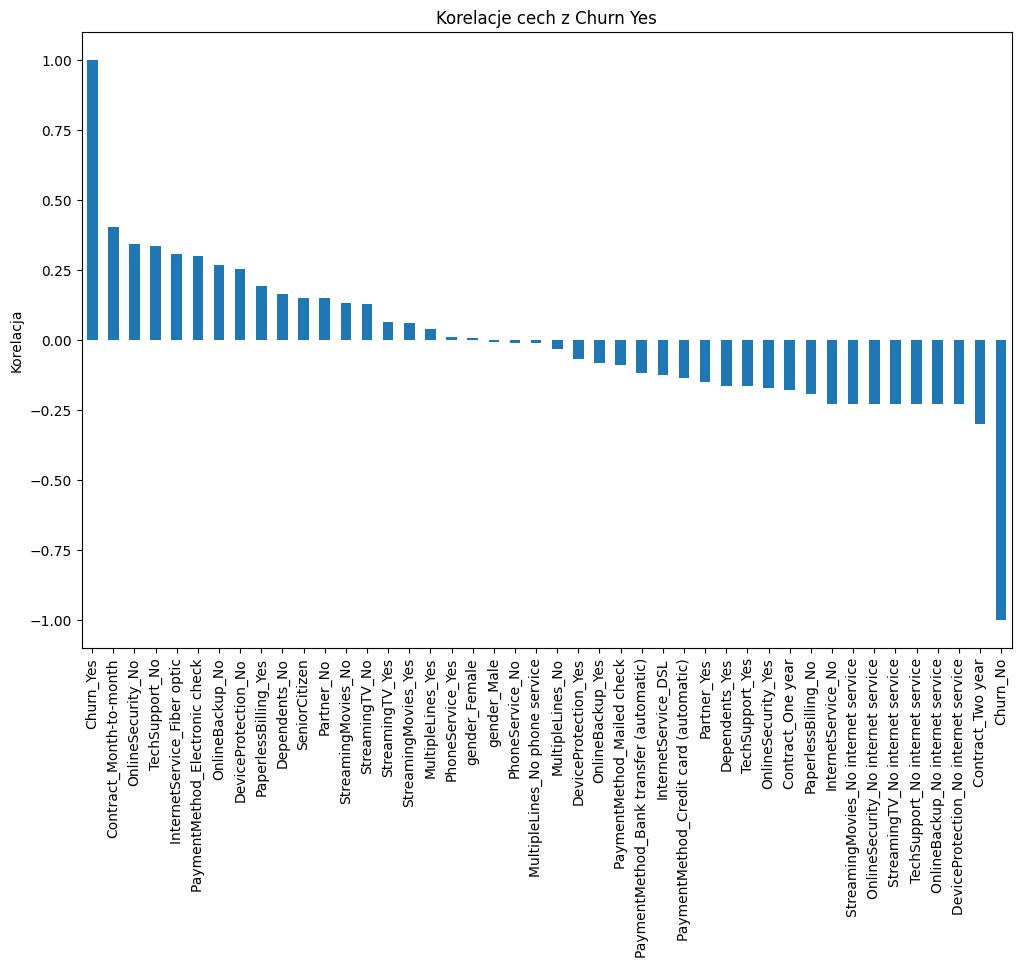

In [49]:
df_corr = df.drop(columns=['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges'])

df_corr = pd.get_dummies(df_corr, drop_first=False)
plt.figure(figsize=(12,8))
correlations = df_corr.corr()['Churn_Yes'].sort_values(ascending=False)
correlations.plot(kind='bar')

plt.title('Korelacje cech z Churn Yes')
plt.ylabel('Korelacja')
plt.show()


1.6. Jakie są rodzaje zawieranych umów?

In [50]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

1.7. Rozkład różnych usług używanych przez klientów.

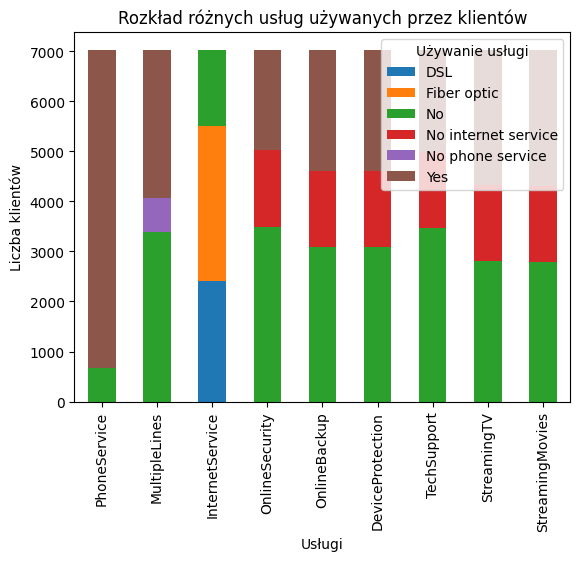

In [51]:
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
service_usage = df[services].apply(pd.Series.value_counts).T
service_usage.plot(kind='bar', stacked=True)
plt.title('Rozkład różnych usług używanych przez klientów')
plt.xlabel('Usługi')
plt.ylabel('Liczba klientów')
plt.legend(title='Używanie usługi', loc='upper right')
plt.show()

1.8. Utworzenie histogramu przedstawiającego rozkład długości czasu korzystania z usług (zmienna
'tenure').
1.9. Utworzenie histogramu przedstawiającego rozkład długości czasu korzystania z usług (zmienna
'tenure'), z różnicowaniem według klientów, którzy odeszli w ciągu ostatniego miesiąca oraz typu
umowy.

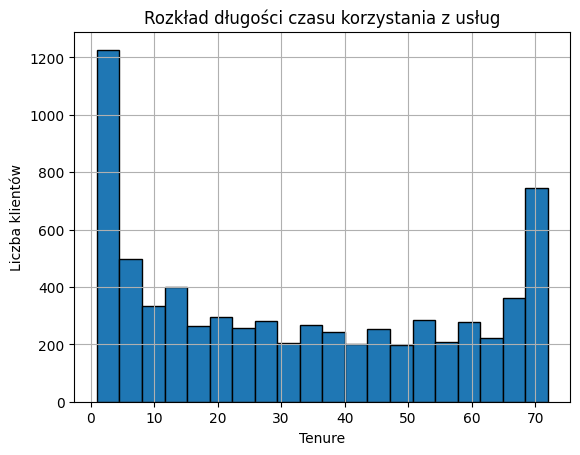

In [52]:
df['tenure'].hist(bins=20, edgecolor = 'black')
plt.title('Rozkład długości czasu korzystania z usług')
plt.xlabel('Tenure')
plt.ylabel('Liczba klientów')
plt.show()


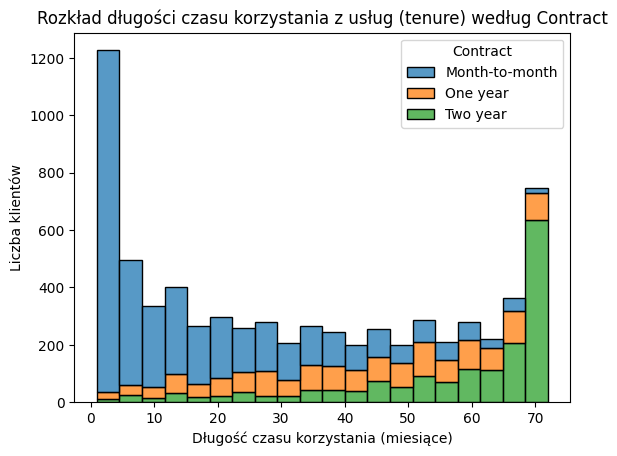

In [53]:
sns.histplot(data=df, x='tenure', hue='Contract', multiple='stack', kde=False, bins=20)
plt.title('Rozkład długości czasu korzystania z usług (tenure) według Contract')
plt.xlabel('Długość czasu korzystania (miesiące)')
plt.ylabel('Liczba klientów')
plt.show()


1.10. Traktując każdą unikalną grupę 'tenure' jako kohortę (kohorta to grupa klientów, którzy mają
wspólną cechę w określonym czasie. W kontekście analizy danych dotyczących churnu, kohorta może
być definiowana na podstawie długości czasu korzystania z usług firmy), należy obliczyć współczynnik
rezygnacji (procent osób, które zadeklarowały rezygnację) dla każdej kohorty. Na przykład w kohorcie
z 1-miesięcznym stażem wskaźnik rezygnacji wynosi 61,99%. Kohorty powinny obejmować staż od 1
do 72 miesięcy, z ogólną tendencją, że im dłuższy czasu korzystania z usług, tym niższy współczynnik
rezygnacji.

In [54]:
cohort_churn_rate = df.groupby('tenure')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
cohort_churn_rate = cohort_churn_rate.reset_index()
cohort_churn_rate.columns = ['Tenure', 'Churn Rate (%)']
cohort_churn_rate

,Tenure,Churn Rate (%)
0,1,61.990212
1,2,51.680672
2,3,47.000000
3,4,47.159091
4,5,48.120301
...,...,...
67,68,9.000000
68,69,8.421053
69,70,9.243697
70,71,3.529412


1.11. Wykres zależności współczynnika rezygnacji od 'tenure' w miesiącach.

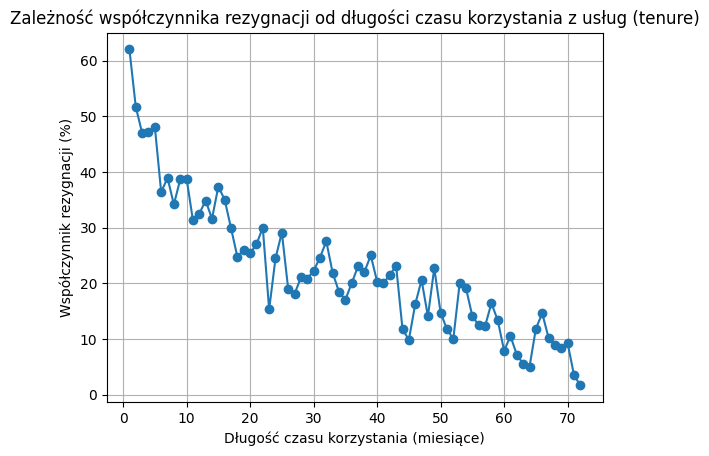

In [55]:
plt.plot(cohort_churn_rate['Tenure'], cohort_churn_rate['Churn Rate (%)'], marker='o')
plt.title('Zależność współczynnika rezygnacji od długości czasu korzystania z usług (tenure)')
plt.xlabel('Długość czasu korzystania (miesiące)')
plt.ylabel('Współczynnik rezygnacji (%)')
plt.grid(True)
plt.show()

1.12. Na podstawie wartości kolumny 'tenure' należy stworzyć nową kolumnę, dzieląc 'tenure' na 4
grupy: '0-12 miesięcy, '12-24 miesięcy, '24-48 miesięcy, ‘Powyżej 48 miesięcy’.

In [56]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-12 miesięcy', '12-24 miesiące', '24-48 miesięcy', 'Powyżej 48 miesięcy'])

1.13. Wykres pudełkowy długości czasu korzystania z usług ('tenure') podzielony na 4 grupy w
zależności od 'Churn'.

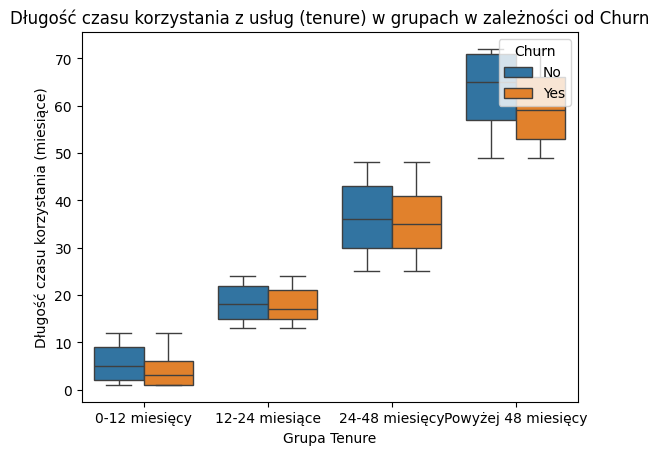

In [57]:
sns.boxplot(x='tenure_group', y='tenure', hue='Churn', data=df)
plt.title('Długość czasu korzystania z usług (tenure) w grupach w zależności od Churn')
plt.xlabel('Grupa Tenure')
plt.ylabel('Długość czasu korzystania (miesiące)')
plt.legend(title='Churn', loc='upper right')
plt.show()

Podział zbioru
2.1. Podział danych na macierz cech oraz etykiety. Należy stworzyć obiekt DataFrame z odpowiednimi
zmiennymi fikcyjnymi. Należy pamiętać, że niektóre kolumny można pominąć.
2.2. Podział zbioru danych na treningowy i testowy, z ustawionym random_state=42, tak aby zbiór
testowy zawierał co najmniej 1100 przykładów.

In [58]:
X = pd.get_dummies(df.drop(columns=['Churn', 'customerID']))
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5625, 49), (1407, 49), (5625,), (1407,))

3. Model drzewa decyzyjnego
3.1. Zastosowanie klasyfikatora drzewa decyzyjnego przy ustawieniach domyślnych.
3.2. Wyświetlenie raportu z klasyfikacji oraz macierzy błędów i drzewo decyzyjne na podstawie
predykcji na zbiorze testowym.
3.3. Informacja nt. wagi cech.

In [60]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print(classification_report(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))


              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1033
           1       0.46      0.48      0.47       374

    accuracy                           0.71      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.71      0.71      1407

[[822 211]
 [193 181]]


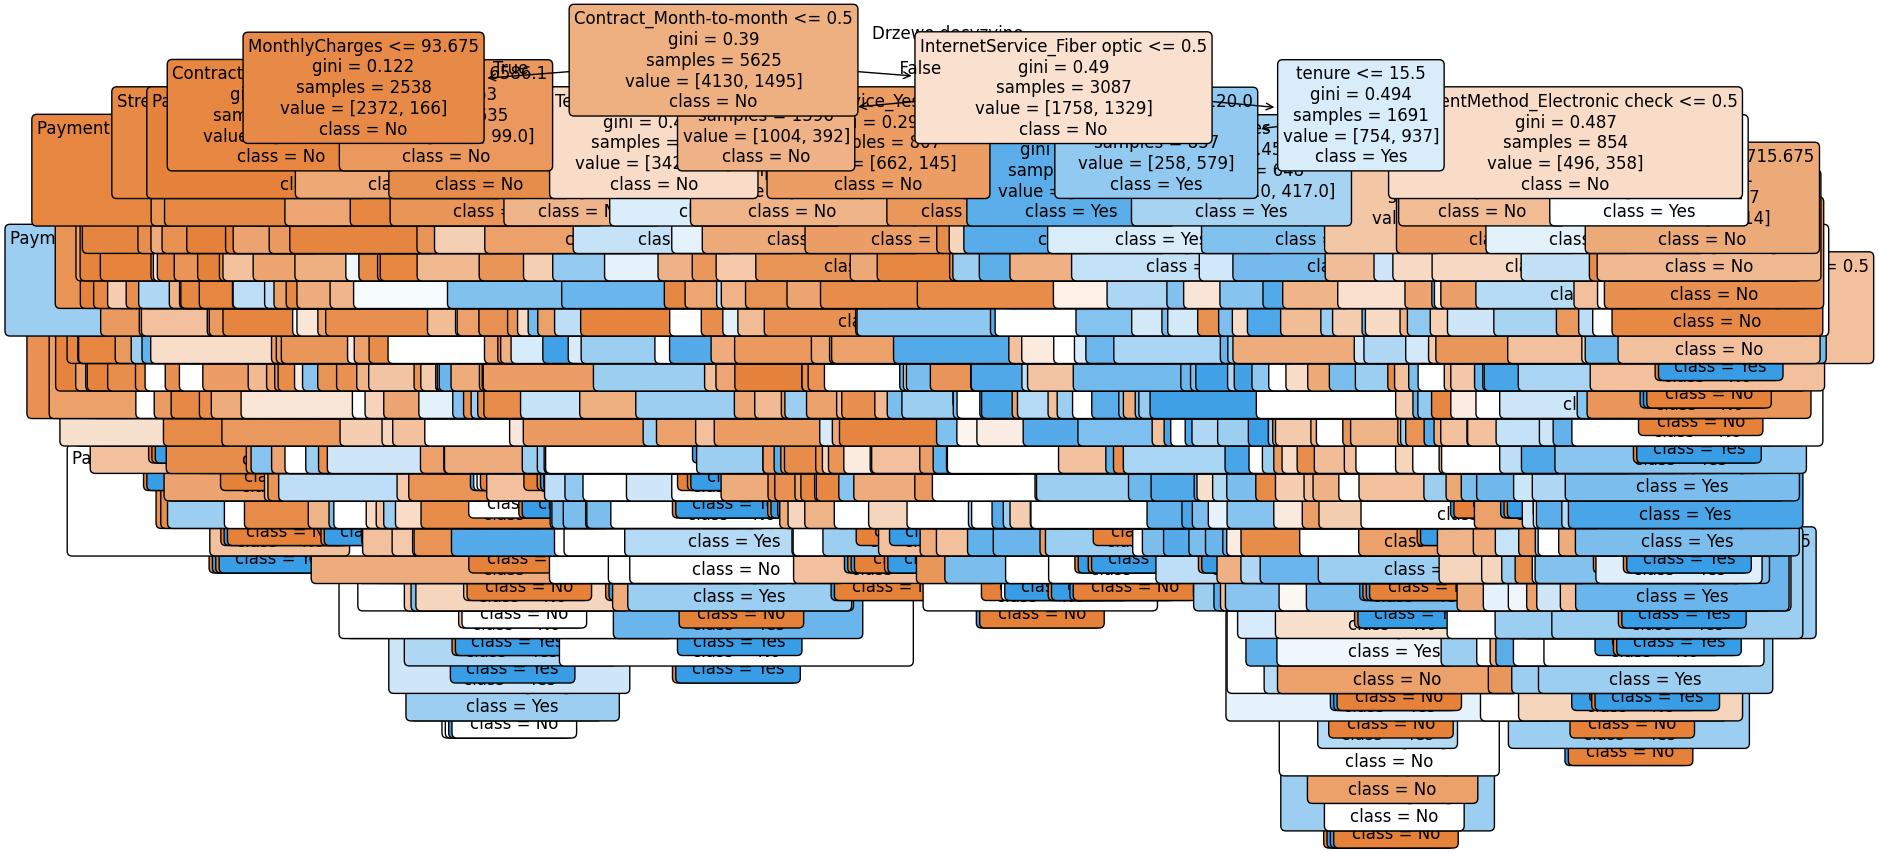

In [61]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=['No', 'Yes'], rounded=True, fontsize=12)
plt.title("Drzewo decyzyjne")
plt.show()


                                    Feature  Importance
2                            MonthlyCharges    0.190311
3                              TotalCharges    0.186171
36                  Contract_Month-to-month    0.170266
1                                    tenure    0.106912
16              InternetService_Fiber optic    0.053131
0                             SeniorCitizen    0.018477
43           PaymentMethod_Electronic check    0.017880
40                     PaperlessBilling_Yes    0.015410
7                               Partner_Yes    0.014813
27                           TechSupport_No    0.013527
8                             Dependents_No    0.013240
23                         OnlineBackup_Yes    0.012845
41  PaymentMethod_Bank transfer (automatic)    0.012283
5                               gender_Male    0.011402
4                             gender_Female    0.011364
44               PaymentMethod_Mailed check    0.010796
9                            Dependents_Yes    0

<Figure size 1200x800 with 0 Axes>

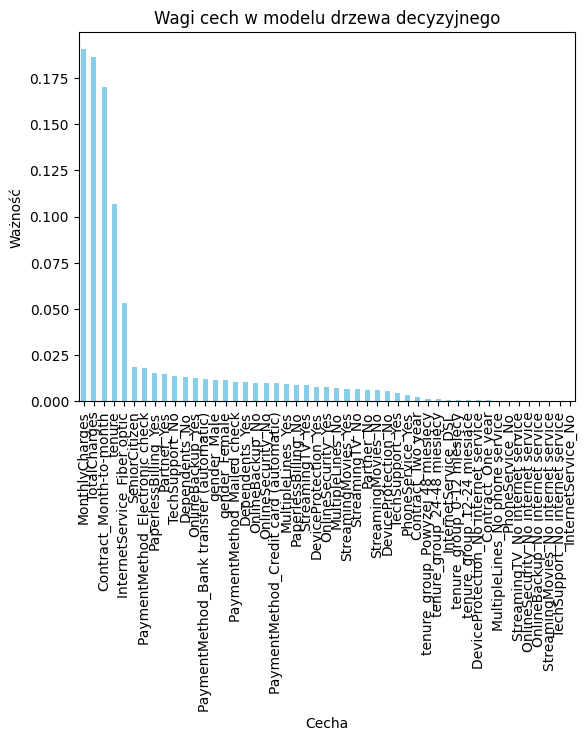

In [62]:
feature_importances = dt_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

print(importance_df)
plt.figure(figsize=(12, 8))

importance_df.plot(kind='bar', x='Feature', y='Importance', legend=False, color='skyblue')
plt.title('Wagi cech w modelu drzewa decyzyjnego')
plt.xlabel('Cecha')
plt.ylabel('Ważność')
plt.xticks(rotation=90)
plt.show()


4. Model k-najbliższych sąsiadów
4.1. Zastosowanie klasyfikatora k-najbliższych sąsiadów przy ustawieniach domyślnych.
4.2. Wyświetlenie raportu z klasyfikacji oraz macierzy błędów na podstawie predykcji na zbiorze
testowym.

In [63]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1033
           1       0.58      0.45      0.51       374

    accuracy                           0.77      1407
   macro avg       0.70      0.67      0.68      1407
weighted avg       0.75      0.77      0.76      1407

[[914 119]
 [207 167]]


5. Model regresji logistycznej
5.1. Zastosowanie klasyfikatora regresji logistycznej przy ustawieniach domyślnych.
5.2. Wyświetlenie raportu z klasyfikacji oraz macierzy błędów na podstawie predykcji na zbiorze
testowym.

In [64]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407

[[931 102]
 [195 179]]


c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Optymalizacja modeli

In [65]:
dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)


best_dt = grid_dt.best_params_, grid_dt.best_score_
print('Najlepsze parametry', best_dt)

best_dt_model = grid_dt.best_estimator_

y_pred_dt = best_dt_model.predict(X_test)

print("Raport z klasyfikacji dla drzewa decyzyjnego zoptymalizowanego:")
print(classification_report(y_test, y_pred_dt))

print("Macierz błędów dla drzewa decyzyjnego zoptymalizowanego:")
print(confusion_matrix(y_test, y_pred_dt))


Najlepsze parametry ({'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}, 0.7953777777777777)
Raport z klasyfikacji dla drzewa decyzyjnego zoptymalizowanego:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1033
           1       0.58      0.57      0.58       374

    accuracy                           0.78      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.78      0.78      0.78      1407

Macierz błędów dla drzewa decyzyjnego zoptymalizowanego:
[[877 156]
 [159 215]]


                                    Feature  Importance
36                  Contract_Month-to-month    0.514815
1                                    tenure    0.168823
16              InternetService_Fiber optic    0.158378
3                              TotalCharges    0.042764
2                            MonthlyCharges    0.038015
27                           TechSupport_No    0.030958
43           PaymentMethod_Electronic check    0.022179
10                          PhoneService_No    0.007694
18                        OnlineSecurity_No    0.005735
38                        Contract_Two year    0.003497
35                      StreamingMovies_Yes    0.003386
4                             gender_Female    0.002337
13           MultipleLines_No phone service    0.001181
33                       StreamingMovies_No    0.000237
37                        Contract_One year    0.000000
32                          StreamingTV_Yes    0.000000
34      StreamingMovies_No internet service    0

<Figure size 1200x800 with 0 Axes>

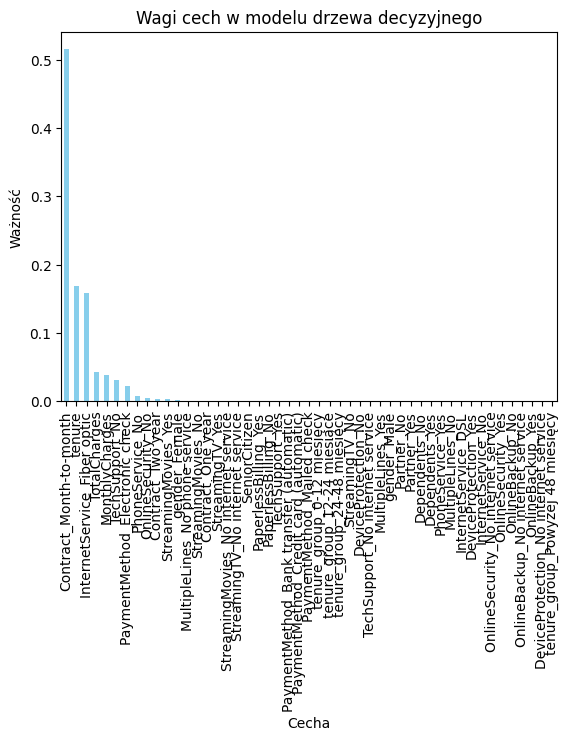

In [66]:
feature_importances_opt = best_dt_model.feature_importances_

importance_df_opt = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances_opt
})

importance_df_opt = importance_df_opt.sort_values(by='Importance', ascending=False)

print(importance_df_opt)
plt.figure(figsize=(12, 8))

importance_df_opt.plot(kind='bar', x='Feature', y='Importance', legend=False, color='skyblue')
plt.title('Wagi cech w modelu drzewa decyzyjnego')
plt.xlabel('Cecha')
plt.ylabel('Ważność')
plt.xticks(rotation=90)
plt.show()


In [67]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 10],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_params_, grid_knn.best_score_
print('Najlepsze parametry', best_knn)

best_knn_model = grid_knn.best_estimator_

y_pred_knn = best_knn_model.predict(X_test)

print("Raport z klasyfikacji dla KNN zoptymalizowanego:")
print(classification_report(y_test, y_pred_knn))

print("Macierz błędów dla KNN zoptymalizowanego:")
print(confusion_matrix(y_test, y_pred_knn))

Najlepsze parametry ({'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'uniform'}, 0.7811555555555556)
Raport z klasyfikacji dla KNN zoptymalizowanego:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87      1033
           1       0.67      0.41      0.51       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407

Macierz błędów dla KNN zoptymalizowanego:
[[957  76]
 [220 154]]


In [68]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2', 'l1'],  
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500],
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), lr_param_grid, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_params_, grid_lr.best_score_

print('Najlepsze parametry', best_lr)

best_lr_model = grid_lr.best_estimator_

y_pred_lr = best_lr_model.predict(X_test)

print("Raport z klasyfikacji dla Logistic Regression zoptymalizowanej:")
print(classification_report(y_test, y_pred_lr))

print("Macierz błędów dla Logistic Regression zoptymalizowanej:")
print(confusion_matrix(y_test, y_pred_lr))


c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which 

Najlepsze parametry ({'C': 0.01, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}, 0.8085333333333333)
Raport z klasyfikacji dla Logistic Regression zoptymalizowanej:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.65      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Macierz błędów dla Logistic Regression zoptymalizowanej:
[[936  97]
 [195 179]]


c:\Users\Garland\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
